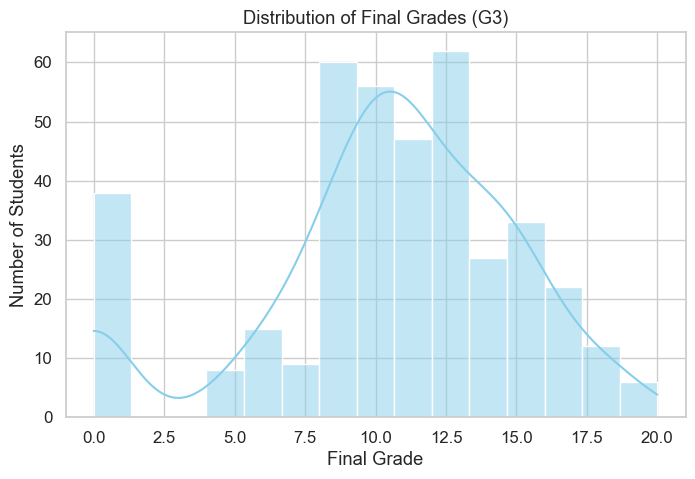

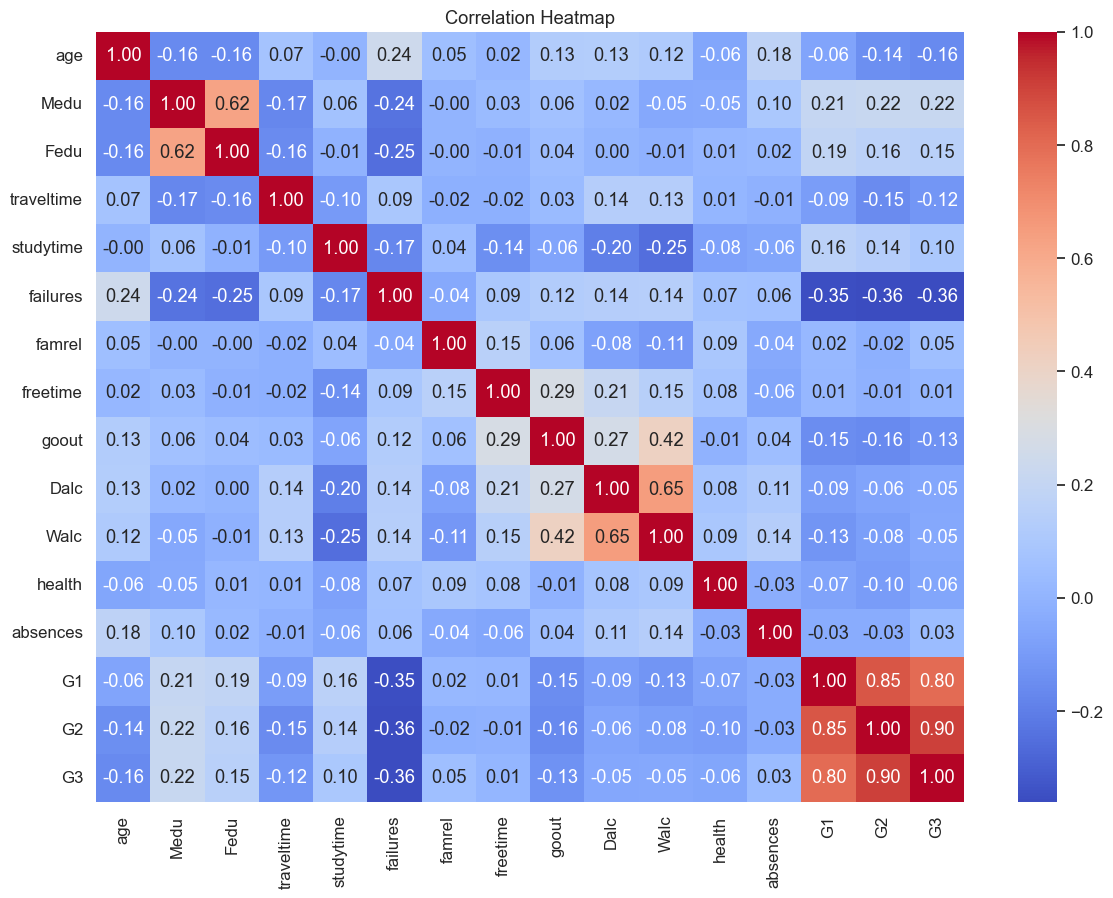

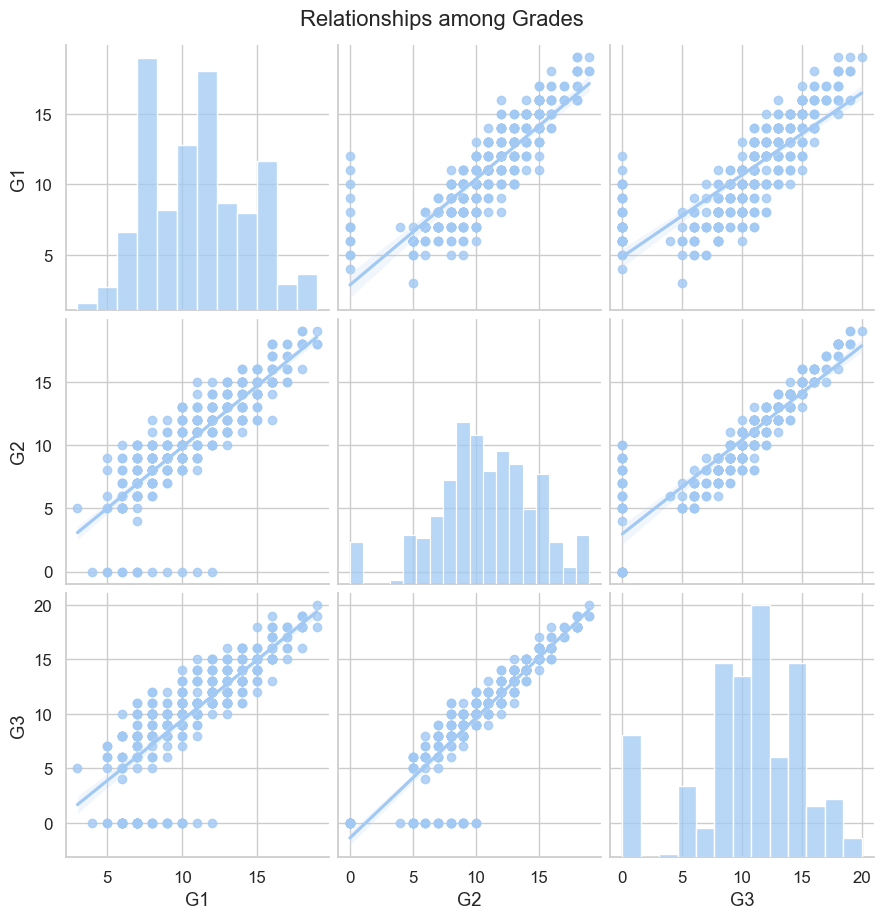


🎯 Mean G3 by 'sex':
            G3
sex           
F     9.966346
M    10.914439


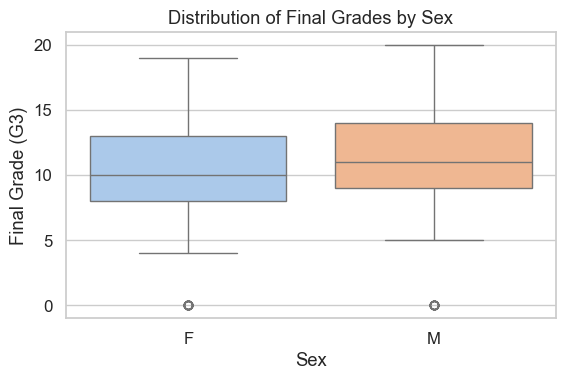


🎯 Mean G3 by 'address':
                G3
address           
R         9.511364
U        10.674267


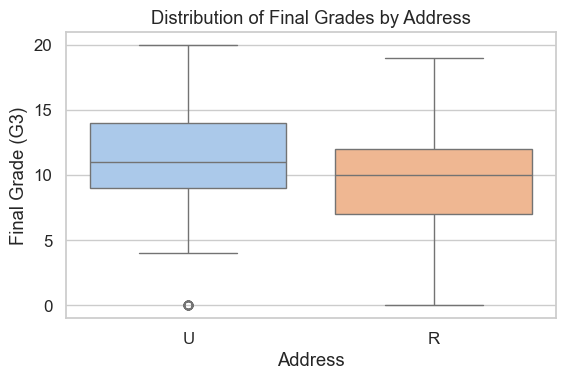


🎯 Mean G3 by 'famsize':
                G3
famsize           
GT3      10.177936
LE3      11.000000


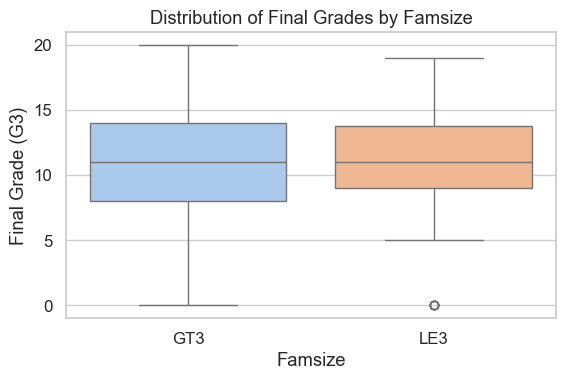


🎯 Mean G3 by 'Pstatus':
                G3
Pstatus           
A        11.195122
T        10.324859


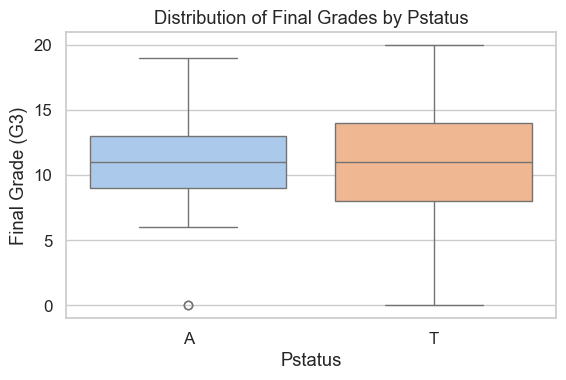

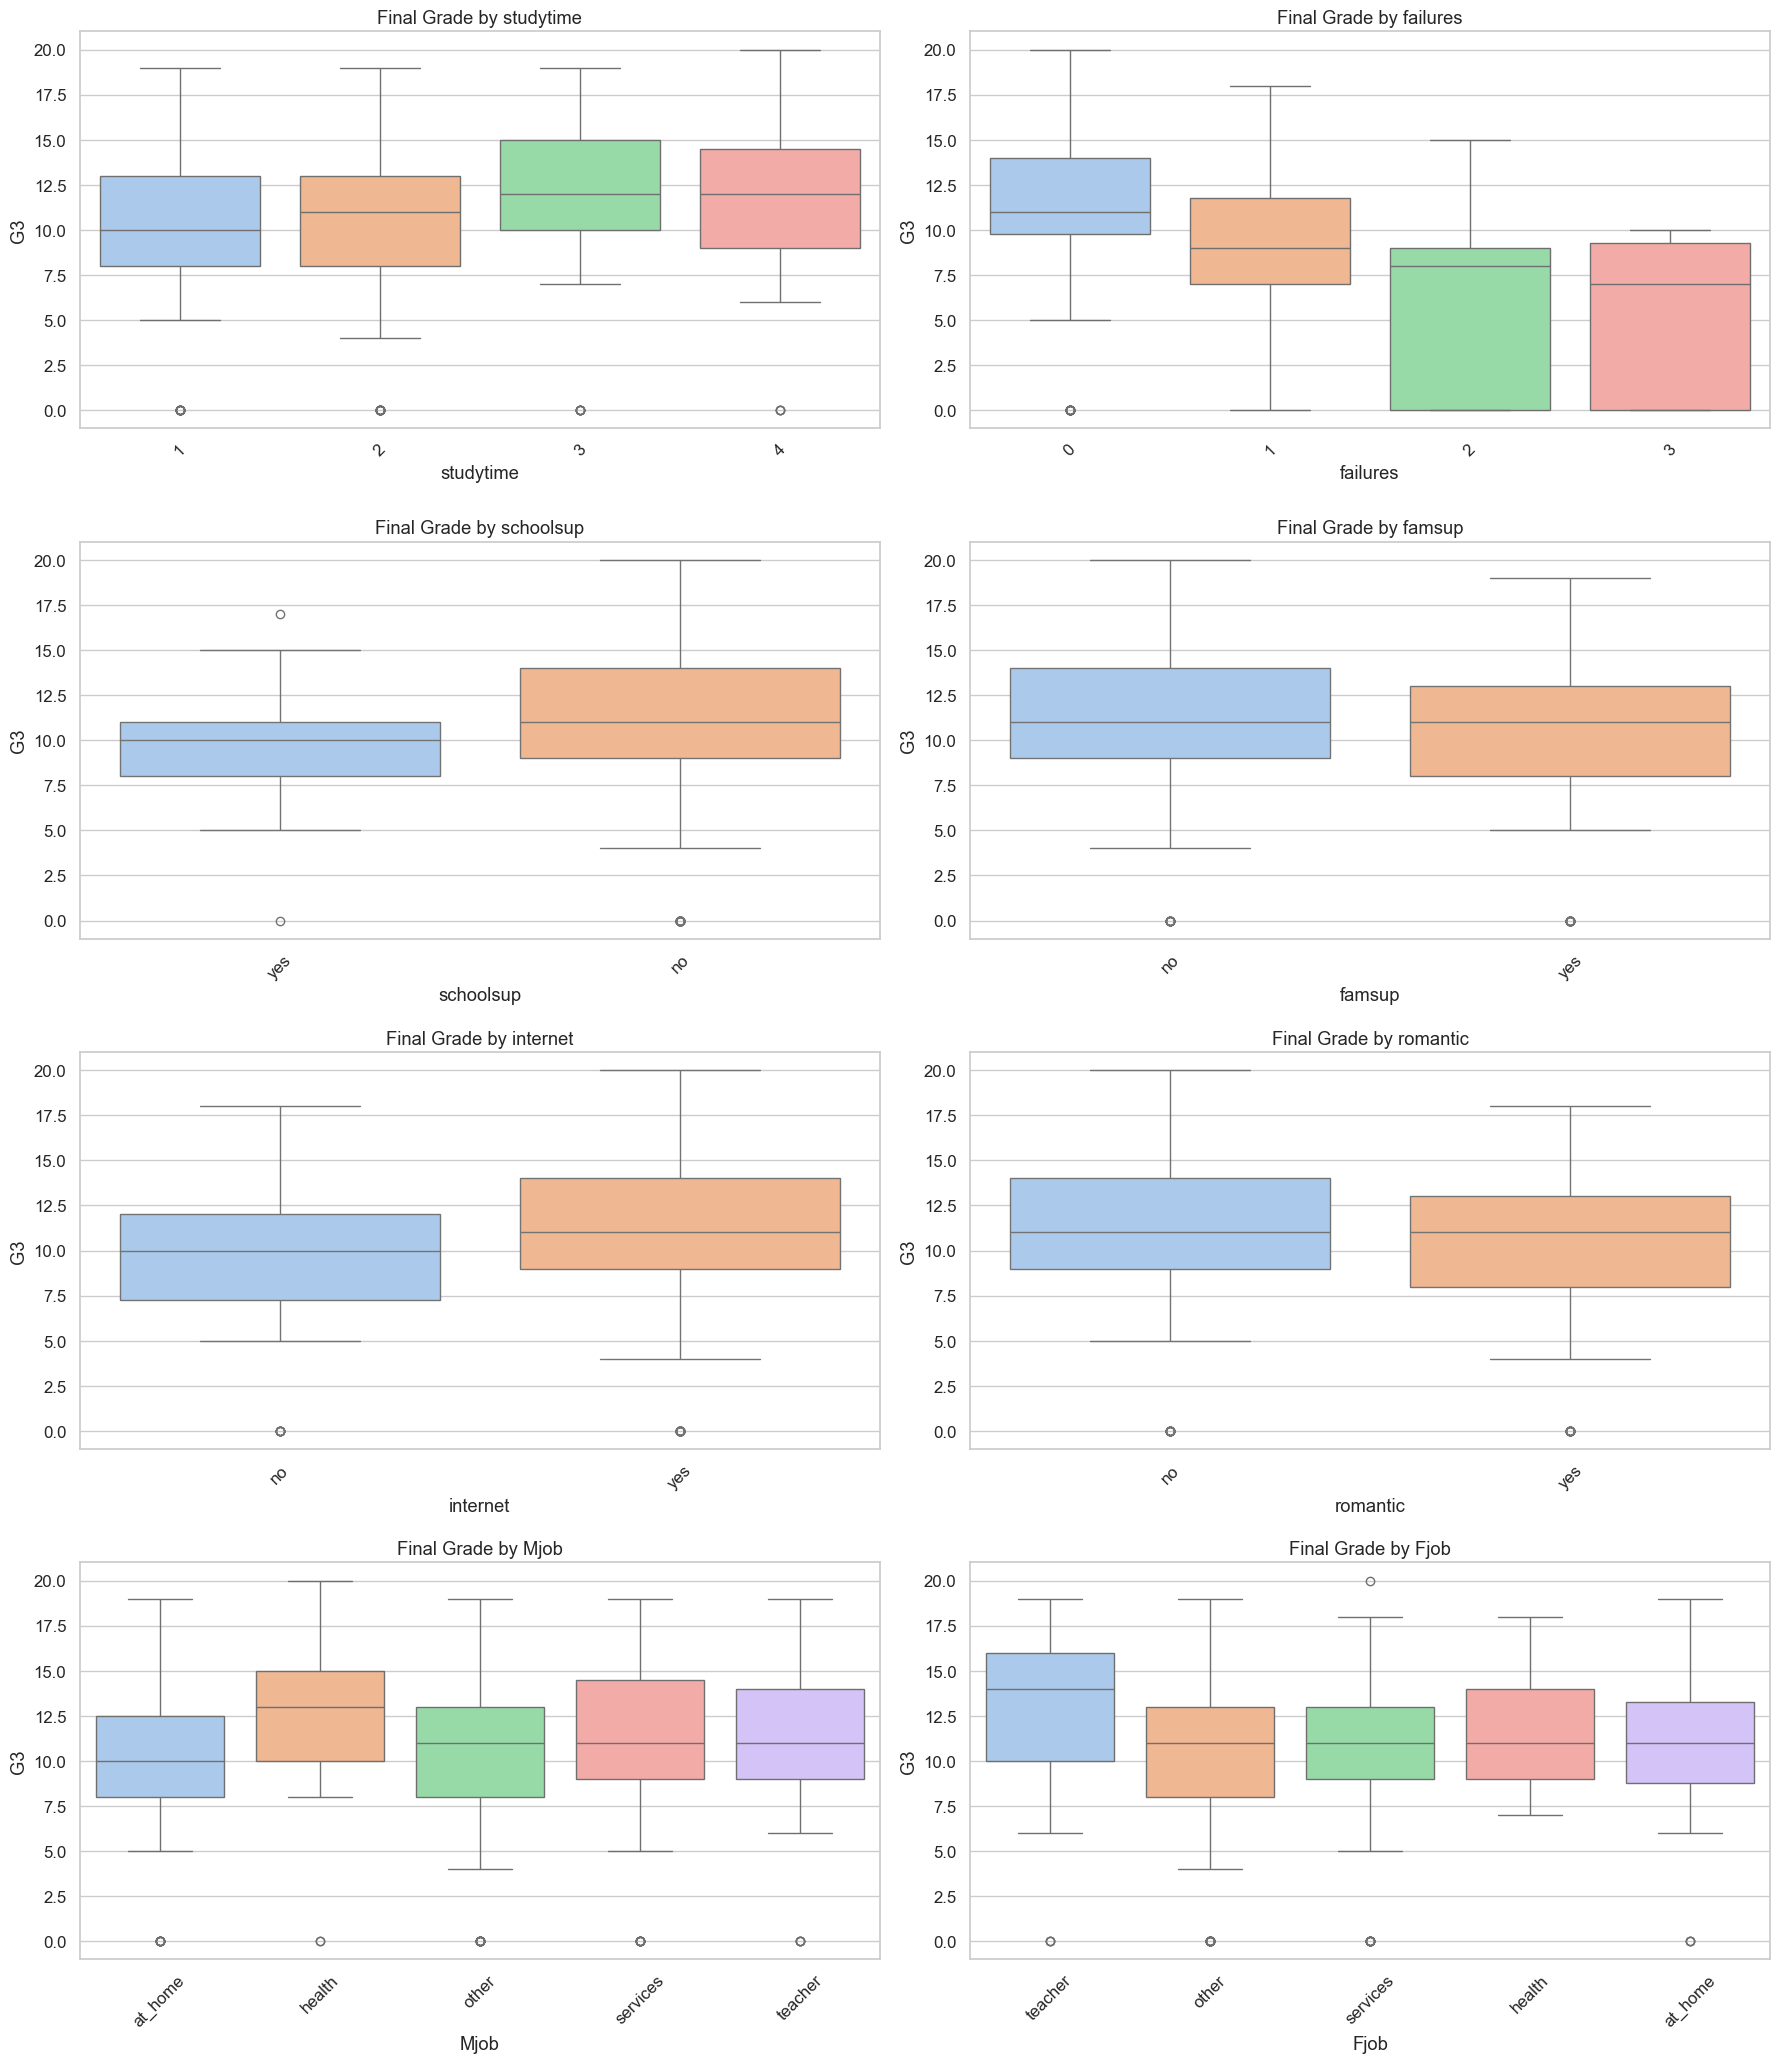

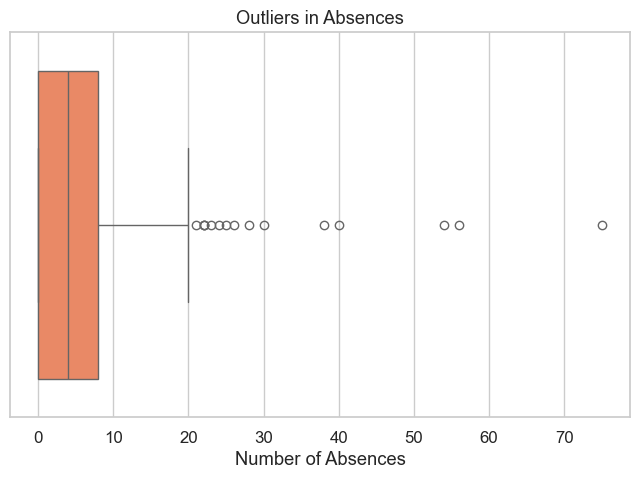

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# Set style
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)

# Load dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")  # or your loaded df

# 1. Distribution of Final Grades
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], kde=True, bins=15, color='skyblue')
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 3. Pairplot of G1, G2, G3
sns.pairplot(df[['G1', 'G2', 'G3']], kind='reg', height=3)
plt.suptitle("Relationships among Grades", y=1.02)
plt.show()

# ✅ 💡 NEW BLOCK: Grouped Means + Boxplots
key_vars = ['sex', 'address', 'famsize', 'Pstatus']
for var in key_vars:
    print(f"\n🎯 Mean G3 by '{var}':")
    print(df[[var, 'G3']].groupby(var).mean())

    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=var, y='G3', hue=var, palette='pastel', legend=False)
    plt.title(f"Distribution of Final Grades by {var.capitalize()}")
    plt.xlabel(var.capitalize())
    plt.ylabel("Final Grade (G3)")
    plt.tight_layout()
    plt.show()

# 4. Boxplots for other categorical variables vs G3
categorical_vars = ['studytime', 'failures', 'schoolsup', 'famsup',
                    'internet', 'romantic', 'Mjob', 'Fjob']

plt.figure(figsize=(18, 25))
for i, var in enumerate(categorical_vars):
    plt.subplot(5, 2, i+1)
    sns.boxplot(data=df, x=var, y='G3', hue=var, palette='pastel', legend=False)
    plt.title(f'Final Grade by {var}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Boxplot for outliers in absences
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['absences'], color='coral')
plt.title("Outliers in Absences")
plt.xlabel("Number of Absences")
plt.show()


In [10]:
import ipywidgets as widgets
from IPython.display import display

slider = widgets.IntSlider(value=5, min=0, max=10)
display(slider)


IntSlider(value=5, max=10)

In [15]:
### 🎛 Interactive Histogram of Final Grades
#Use the slider to adjust the number of bins and explore the distribution of final grades (`G3`).
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")

# Create a slider for bin size
bins_slider = widgets.IntSlider(value=10, min=5, max=30, step=1, description='Bins:')

@interact(bins=widgets.IntSlider(min=5, max=30, step=1, value=10))
def plot_histogram(bins):
    plt.figure(figsize=(8, 5))
    sns.histplot(df['G3'], kde=True, bins=bins, color='skyblue')
    plt.title(f"Distribution of Final Grades (G3) with {bins} Bins")
    plt.xlabel("Final Grade")
    plt.ylabel("Number of Students")
    plt.show()


interactive(children=(IntSlider(value=10, description='bins', max=30, min=5), Output()), _dom_classes=('widget…

In [12]:
### 📊 Correlation Heatmap
#Choose a correlation method (Pearson, Kendall, Spearman) to see how features relate to each other.
from ipywidgets import interact
import matplotlib.pyplot as plt
import seaborn as sns

@interact(method=['pearson', 'kendall', 'spearman'])
def plot_heatmap(method):
    plt.figure(figsize=(10, 8))

    # Select only numeric columns for correlation
    numeric_df = df.select_dtypes(include=['number'])

    corr = numeric_df.corr(method=method)
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)

    plt.title(f"Correlation Heatmap ({method.title()} Method)")
    plt.tight_layout()
    plt.show()


interactive(children=(Dropdown(description='method', options=('pearson', 'kendall', 'spearman'), value='pearso…

In [13]:
from ipywidgets import interact, Dropdown
import seaborn as sns
import matplotlib.pyplot as plt

# Dropdown for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

@interact(category=Dropdown(options=categorical_cols, description='Category:'))
def plot_boxplot(category):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=category, y='G3', data=df, hue=category, palette='pastel', legend=False)
    plt.title(f'Final Grades (G3) by {category}')
    plt.xlabel(category)
    plt.ylabel('Final Grade (G3)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


interactive(children=(Dropdown(description='Category:', options=('school', 'sex', 'address', 'famsize', 'Pstat…

In [21]:
# 🔥 Fancy Mode: Interactive Filtering + Scatter Plot
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 14, 17, 22], labels=['<15', '15-17', '18+'])

# 🎛️ Widgets for Filtering
school_dropdown = widgets.Dropdown(
    options=['All'] + sorted(df['school'].unique().tolist()),
    value='All',
    description='School:'
)

sex_dropdown = widgets.Dropdown(
    options=['All'] + sorted(df['sex'].unique().tolist()),
    value='All',
    description='Sex:'
)

age_dropdown = widgets.Dropdown(
    options=['All'] + df['age_group'].unique().tolist(),
    value='All',
    description='Age Group:'
)

study_slider = widgets.IntSlider(
    value=2,
    min=int(df['studytime'].min()),
    max=int(df['studytime'].max()),
    step=1,
    description='Study Time:',
    continuous_update=False
)

internet_checkbox = widgets.Checkbox(
    value=False,
    description='Only w/ Internet'
)

medu_slider = widgets.IntSlider(
    value=2,
    min=int(df['Medu'].min()),
    max=int(df['Medu'].max()),
    step=1,
    description="Mother's Edu:"
)

# 🎯 Dropdowns for scatterplot axes
numeric_columns = df.select_dtypes(include='number').columns.tolist()

x_dropdown = widgets.Dropdown(
    options=numeric_columns,
    value='G1',
    description='X-axis:'
)

y_dropdown = widgets.Dropdown(
    options=numeric_columns,
    value='G3',
    description='Y-axis:'
)

# ✨ Final Plotting Function
def update_scatter(x, y, school, sex, age_group, studytime, internet, medu):
    filtered_df = df.copy()
    
    if school != 'All':
        filtered_df = filtered_df[filtered_df['school'] == school]
    if sex != 'All':
        filtered_df = filtered_df[filtered_df['sex'] == sex]
    if age_group != 'All':
        filtered_df = filtered_df[filtered_df['age_group'] == age_group]
    if internet:
        filtered_df = filtered_df[filtered_df['internet'] == 'yes']
    
    filtered_df = filtered_df[filtered_df['studytime'] >= studytime]
    filtered_df = filtered_df[filtered_df['Medu'] >= medu]

    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=filtered_df, x=x, y=y, hue='sex', palette='coolwarm')
    plt.title(f"{x} vs {y} | Filtered View")
    plt.grid(True)
    plt.show()

# 🧩 UI Layout
ui = widgets.VBox([
    widgets.HBox([x_dropdown, y_dropdown]),
    widgets.HBox([school_dropdown, sex_dropdown, age_dropdown]),
    widgets.HBox([study_slider, internet_checkbox, medu_slider])
])

out = widgets.interactive_output(
    update_scatter, {
        'x': x_dropdown, 
        'y': y_dropdown, 
        'school': school_dropdown, 
        'sex': sex_dropdown, 
        'age_group': age_dropdown,
        'studytime': study_slider,
        'internet': internet_checkbox,
        'medu': medu_slider
    })

display(ui, out)


Output()